### Unexpected machine failures can lead to production downtime,increased maintenance costs, and operational disruptions.The objective of this project is to predict machine failures using operational sensor data and identify the most important factors contributing to failure risk.

## *Importing required libraries*

In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [90]:
data = pd.read_csv("ai4i2020.csv")

*Checking the samples of data*

In [91]:
data.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,1,M14860,M,298.1,308.6,1551,42.8,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0


In [92]:
data.tail()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0
9999,10000,M24859,M,299.0,308.7,1500,40.2,30,0


*Dropping the UDI  column as it is just a serial number*

In [93]:
data = data.drop (columns="UDI")

In [94]:
data

,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,M14860,M,298.1,308.6,1551,42.8,0,0
1,L47181,L,298.2,308.7,1408,46.3,3,0
2,L47182,L,298.1,308.5,1498,49.4,5,0
3,L47183,L,298.2,308.6,1433,39.5,7,0
4,L47184,L,298.2,308.7,1408,40.0,9,0
...,...,...,...,...,...,...,...,...
9995,M24855,M,298.8,308.4,1604,29.5,14,0
9996,H39410,H,298.9,308.4,1632,31.8,17,0
9997,M24857,M,299.0,308.6,1645,33.4,22,0
9998,H39412,H,299.0,308.7,1408,48.5,25,0


*Data types of columns inspection and null values checking*

In [95]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Product ID               10000 non-null  object 
 1   Type                     10000 non-null  object 
 2   Air temperature [K]      10000 non-null  float64
 3   Process temperature [K]  10000 non-null  float64
 4   Rotational speed [rpm]   10000 non-null  int64  
 5   Torque [Nm]              10000 non-null  float64
 6   Tool wear [min]          10000 non-null  int64  
 7   Machine failure          10000 non-null  int64  
dtypes: float64(3), int64(3), object(2)
memory usage: 625.1+ KB


In [96]:
data.describe()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


*We can observe the target  value has huge data imbalance*

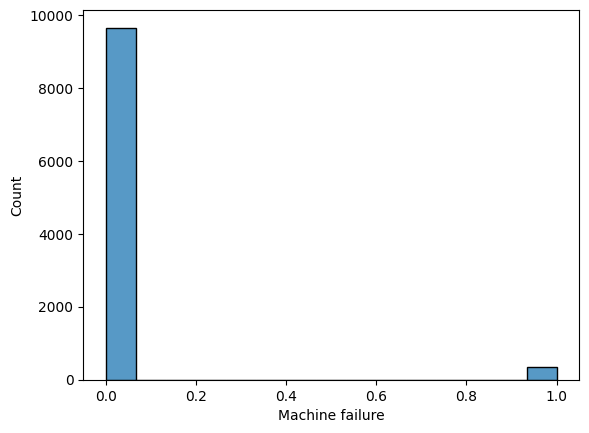

In [97]:
sns.histplot(data["Machine failure"])
plt.show()

*Low-quality (L) machines exhibit nearly double the failure rate of high-quality (H) machines, suggesting machine type is an important predictor of failure risk*

In [98]:
pd.crosstab(
    data['Type'],
    data['Machine failure'],
    normalize='index'
)*100

Machine failure,0,1
Type,,
H,97.906281,2.093719
L,96.083333,3.916667
M,97.230564,2.769436


# ** INSIGHTS FROM THE HEATMAP**

*   Torque has the highest correlation with the machine failure and tool wear second highest
*   Rotational speed and torque  are highly negatively correlated  mainly due to  Higher torque often occurs at lower RPM.


*   Air process and Air temperature have high correlation








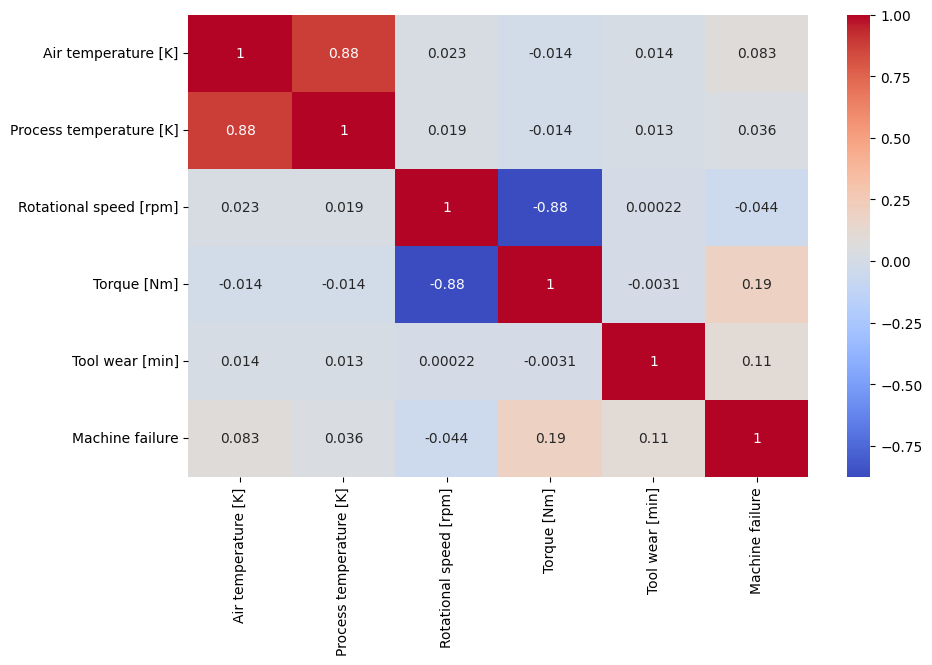

In [99]:


plt.figure(figsize=(10,6))
sns.heatmap(data.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.savefig("correlation_heatmap.jpg")
plt.show()

In [16]:
failed = data[data['Machine failure']==1]
normal = data[data['Machine failure']==0]

***Tool wear of the failed is relatively higher than normal ones***

In [18]:
failed.describe()


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
count,339.000000,339.000000,339.000000,339.000000,339.000000,339.0
mean,300.886431,310.290265,1496.486726,50.168142,143.781711,1.0
std,2.071473,1.363686,384.943547,16.374498,72.759876,0.0
min,295.600000,306.100000,1181.000000,3.800000,0.000000,1.0
25%,299.100000,309.500000,1326.500000,45.950000,84.500000,1.0
50%,301.600000,310.400000,1365.000000,53.700000,165.000000,1.0
75%,302.500000,311.200000,1421.500000,61.200000,207.500000,1.0
max,304.400000,313.700000,2886.000000,76.600000,253.000000,1.0


In [19]:

normal.describe()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
count,9661.000000,9661.000000,9661.000000,9661.000000,9661.000000,9661.0
mean,299.973999,309.995570,1540.260014,39.629655,106.693717,0.0
std,1.990748,1.486846,167.394734,9.472080,62.945790,0.0
min,295.300000,305.700000,1168.000000,12.600000,0.000000,0.0
25%,298.300000,308.800000,1429.000000,33.100000,52.000000,0.0
50%,300.000000,310.000000,1507.000000,39.900000,107.000000,0.0
75%,301.500000,311.100000,1615.000000,46.300000,160.000000,0.0
max,304.500000,313.800000,2695.000000,70.000000,246.000000,0.0


***Machines experiencing failure generally operate under substantially higher torque loads, suggesting mechanical stress is a major contributor to failure event***

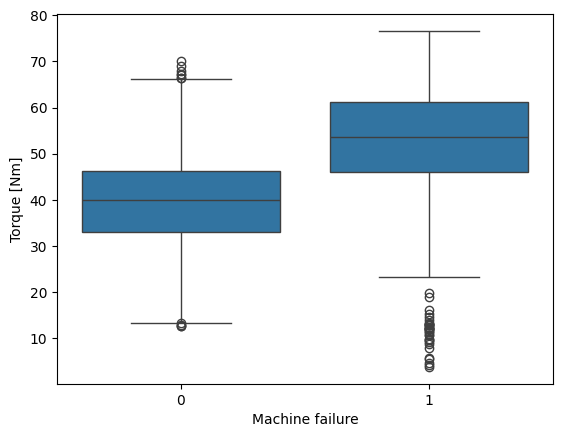

In [29]:
sns.boxplot(x='Machine failure',
            y='Torque [Nm]',
            data=data)

plt.savefig("Torque_boxplot.jpg")
plt.show()

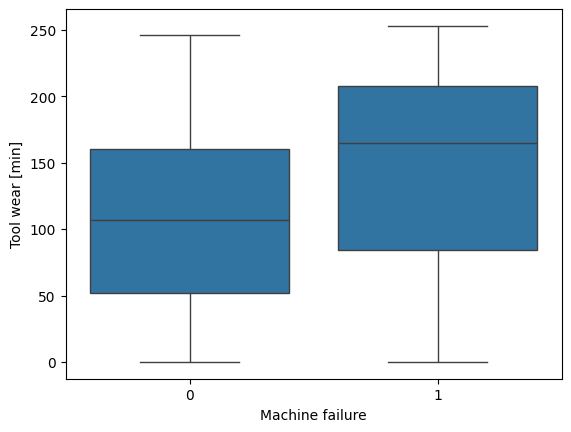

In [30]:
sns.boxplot(x='Machine failure',
            y='Tool wear [min]',
            data=data)

plt.savefig("Tool_wear_boxplot.jpg")
plt.show()

Product ID and Type represent the same data so dropping Product ID as it is redundant

In [32]:
data = data.drop(columns="Product ID")

In [33]:
data

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0
...,...,...,...,...,...,...,...
9995,M,298.8,308.4,1604,29.5,14,0
9996,H,298.9,308.4,1632,31.8,17,0
9997,M,299.0,308.6,1645,33.4,22,0
9998,H,299.0,308.7,1408,48.5,25,0


# Seperating the target column from the dataset

In [38]:
X = data.drop('Machine failure', axis=1)
y = data['Machine failure']

In [42]:
x

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,298.1,308.6,1551,42.8,0
1,298.2,308.7,1408,46.3,3
2,298.1,308.5,1498,49.4,5
3,298.2,308.6,1433,39.5,7
4,298.2,308.7,1408,40.0,9
...,...,...,...,...,...
9995,298.8,308.4,1604,29.5,14
9996,298.9,308.4,1632,31.8,17
9997,299.0,308.6,1645,33.4,22
9998,299.0,308.7,1408,48.5,25


In [40]:
y

,Machine failure
0,0
1,0
2,0
3,0
4,0
...,...
9995,0
9996,0
9997,0
9998,0


***Train and test splitting while keeping the same distribution of Machine failure using stratify***

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

***One hot encoding of Type column***





In [47]:
X_train = pd.get_dummies(X_train, columns=['Type'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['Type'], drop_first=True)



In [48]:
X_train

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type_L,Type_M
4058,302.0,310.9,1456,47.2,54,False,True
1221,297.0,308.3,1399,46.4,132,False,True
6895,301.0,311.6,1357,45.6,137,False,True
9863,298.9,309.8,1411,56.3,84,True,False
8711,297.1,308.5,1733,28.7,50,True,False
...,...,...,...,...,...,...,...
980,296.1,306.7,1409,42.8,134,True,False
4266,302.7,311.1,1440,39.5,146,True,False
7772,300.3,311.5,1464,41.0,29,False,False
5780,301.7,311.2,1517,42.4,113,True,False


In [49]:
X_test


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type_L,Type_M
2997,300.5,309.8,1345,62.7,153,True,False
4871,303.7,312.4,1513,40.1,135,True,False
3858,302.5,311.4,1559,37.6,209,True,False
951,295.6,306.3,1509,35.8,60,False,False
6463,300.5,310.0,1358,60.4,102,False,False
...,...,...,...,...,...,...,...
1686,297.9,307.3,1663,28.7,7,False,False
6952,300.8,311.3,1498,40.2,73,True,False
9954,298.1,307.9,1446,42.8,121,False,True
5728,302.4,311.9,1422,46.4,194,False,True


# **Logistic Regression**

In [50]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [58]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

*The Logistic Regression model achieved high recall (82%), successfully identifying most failure events. However, it generated a substantial number of false positives, leading to low precision. This suggests the model is suitable as an initial screening tool but would require further refinement to reduce unnecessary maintenance action*

In [59]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1       :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))


Accuracy : 0.8275
Precision: 0.14395886889460155
Recall   : 0.8235294117647058
F1       : 0.24507658643326038
ROC AUC  : 0.9068855803190842


In [61]:
y_prob = model.predict_proba(X_test)[:,1]

y_pred_07 = (y_prob >= 0.7).astype(int)

Threshold tuning was performed to balance failure detection and false alarm rates. Increasing the decision threshold improved precision from 14% to 24% while reducing recall from 82% to 71%, illustrating the trade-off between missed failures and unnecessary maintenance actions

In [62]:
print("Accuracy :", accuracy_score(y_test, y_pred_07))
print("Precision:", precision_score(y_test, y_pred_07))
print("Recall   :", recall_score(y_test, y_pred_07))
print("F1       :", f1_score(y_test, y_pred_07))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.914
Precision: 0.24
Recall   : 0.7058823529411765
F1       : 0.3582089552238806
ROC AUC  : 0.9068855803190842


Although a threshold of 0.7 reduced false positives, it also increased the number of missed failures. Since preventing unexpected equipment failures is the primary business objective, the 0.5 threshold was chosen because it achieved higher recall (82.4%) and better aligned with predictive maintenance requirements.

# ***Random Forest Classifier***

In [63]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rfc.fit(X_train, y_train)
y_pred = rfc.predict(X_test)

y_prob = rfc.predict_proba(X_test)[:,1]

***Random Forest significantly improved model discrimination, achieving a ROC-AUC of 0.963 compared to 0.907 for Logistic Regression. While the model produced substantially fewer false alarms (precision 94%), it detected fewer failures (recall 47%), highlighting the trade-off between maintenance efficiency and failure detection.***

In [64]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1       :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.981
Precision: 0.9411764705882353
Recall   : 0.47058823529411764
F1       : 0.6274509803921569
ROC AUC  : 0.9632276823772989


In [65]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rfc.feature_importances_
})

importance.sort_values(
    by='Importance',
    ascending=False
)

,Feature,Importance
3,Torque [Nm],0.312612
2,Rotational speed [rpm],0.289263
4,Tool wear [min],0.209803
0,Air temperature [K],0.100226
1,Process temperature [K],0.071705
5,Type_L,0.009284
6,Type_M,0.007107


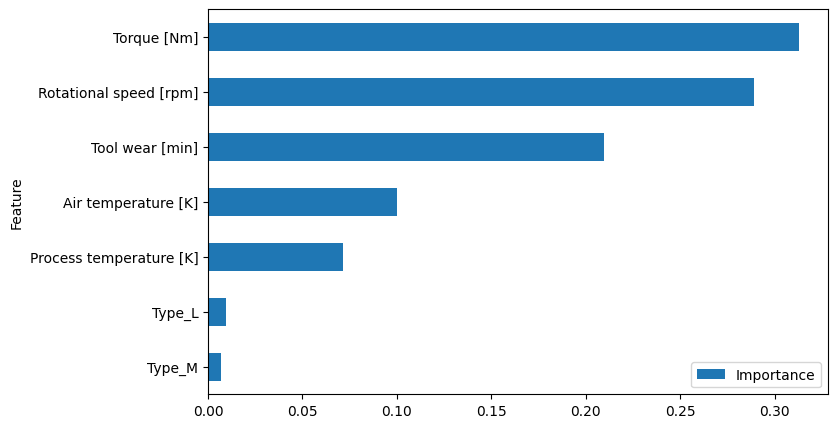

In [67]:
import matplotlib.pyplot as plt

importance.sort_values(
    by='Importance',
    ascending=True
).plot(
    x='Feature',
    y='Importance',
    kind='barh',
    figsize=(8,5)
)
plt.savefig("feature_imp.jpg")
plt.show()

In [68]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[1930    2]
 [  36   32]]


In [69]:
y_prob = rfc.predict_proba(X_test)[:,1]

y_pred_03 = (y_prob >= 0.3).astype(int)

In [70]:
print("Accuracy :", accuracy_score(y_test, y_pred_03))
print("Precision:", precision_score(y_test, y_pred_03))
print("Recall   :", recall_score(y_test, y_pred_03))
print("F1       :", f1_score(y_test, y_pred_03))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.9835
Precision: 0.7868852459016393
Recall   : 0.7058823529411765
F1       : 0.7441860465116279
ROC AUC  : 0.9632276823772989


Threshold optimization was performed on the Random Forest model to balance maintenance efficiency and failure detection. By lowering the classification threshold, recall increased from 47% to 71% while maintaining a precision of 79%, resulting in an F1-score of 0.74 and ROC-AUC of 0.96. The final model provided a practical trade-off between preventing unexpected equipment failures and minimizing unnecessary maintenance actions.

# ***XGBOOST***

In [71]:
!pip install xgboost -q

In [72]:
from xgboost import XGBClassifier

In [73]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos

print(scale_pos_weight)

28.52029520295203


In [76]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)



Changing the feature names as feature_names must be string for XGBoost

In [79]:
X_train.columns = (
    X_train.columns
    .str.replace('[^A-Za-z0-9_]', '_', regex=True)
)

X_test.columns = (
    X_test.columns
    .str.replace('[^A-Za-z0-9_]', '_', regex=True)
)

In [80]:
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [81]:
y_pred = xgb.predict(X_test)

y_prob = xgb.predict_proba(X_test)[:,1]

In [82]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1       :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.9555
Precision: 0.4222222222222222
Recall   : 0.8382352941176471
F1       : 0.5615763546798029
ROC AUC  : 0.9716386554621849


In [83]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1854   78]
 [  11   57]]


In [87]:
y_pred_03 = (y_prob >= 0.3).astype(int)

print("Precision:", precision_score(y_test, y_pred_03))
print("Recall   :", recall_score(y_test, y_pred_03))
print("F1       :", f1_score(y_test, y_pred_03))

Precision: 0.30845771144278605
Recall   : 0.9117647058823529
F1       : 0.46096654275092935


*Three machine learning models were evaluated for predictive maintenance: Logistic Regression, Random Forest, and XGBoost. While XGBoost achieved the highest ROC-AUC score (0.972) and recall (83.8%), it generated a larger number of false positives. After threshold optimization, the Random Forest model achieved the best balance between failure detection and maintenance efficiency, with 78.7% precision, 70.6% recall, and an F1-score of 0.744.

Feature importance analysis identified torque, rotational speed, and tool wear as the primary drivers of machine failure. Based on both predictive performance and operational considerations, the tuned Random Forest model was selected as the final model for deployment because it effectively balanced failure detection with minimizing unnecessary maintenance interventions.
*

***Saving the RandomForestClassifier model***

In [88]:
import joblib

joblib.dump(rfc, 'predictive_maintenance_model.pkl')

['predictive_maintenance_model.pkl']